### Private SLI Predictions



In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

df = pd.read_csv("data.csv")

df = df[df['Private Service Line Material'].isin(['LEAD', 'NOT LEAD'])]

# Convert target variable to binary values
df['Private Service Line Material'] = df['Private Service Line Material'].map({'LEAD': 1, 'NOT LEAD': 0})


categorical_features = [
    'Wall Material', 'Roof Material', 'Basement', 'Basement Finish', 
    'Central Air Conditioning', 'Garage 1 Material','Garage 1 Size', 'Garage 1 Attached', 
    'Use', 'Type of Residence', 'Flood Risk Factor', 'withinmr100',
     'school_elem_district', 'school_hs_district', 'township_name', 'Central Heating', 'FEMA Floodplain', 'Repair Condition', 'withinmr101300'
]
#removed based on control: Central Heating, FEMA Floodplain, Repair Condition, within101300, 'Bedrooms', 'Fireplaces'
#removed based on low correlation: 'Tax Rate', 
numerical_features = [
    'Land Square Feet', 'Age', 'Rooms', 'Full Baths',
    'Half Baths', 'Garage 1 Area', 'Building Square Feet', 'longitude',
    'latitude', 'tract_pop', 'tract_white_perc', 'tract_black_perc', 'tract_asian_perc', 'tract_his_perc',
    'tract_other_perc', 'Tract Median Income', 'Bedrooms', 'Fireplaces'
]
#random noise
#np.random.seed(0)
#df['random_noise'] = np.random.rand(len(df))
#numerical_features.append('random_noise')

#Numerical: Fill missing values with median
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
   # ('scaler', StandardScaler())
])

#Categorical: Fill missing values with the most frequent value & one-hot encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

#Combine Transformers into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])



X = df.drop(columns=['Private Service Line Material'])
y = df['Private Service Line Material']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete.")

Preprocessing complete.


## Get Counts 

In [13]:
print("Training set distribution:")
print(y_train.value_counts())
print()

print("Test set distribution:")
print(y_test.value_counts())

Training set distribution:
Private Service Line Material
1    87497
0    37764
Name: count, dtype: int64

Test set distribution:
Private Service Line Material
1    21875
0     9441
Name: count, dtype: int64


# Train Classifier

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import numpy as np


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,     
    class_weight='balanced',       
    min_samples_split=10,   
    min_samples_leaf=5,      
    max_features='sqrt',     
    random_state=0,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

# Get Classifier Results


Training Set Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75     37764
           1       0.88      0.92      0.90     87497

    accuracy                           0.86    125261
   macro avg       0.84      0.82      0.83    125261
weighted avg       0.85      0.86      0.86    125261


Testing Set Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      9441
           1       0.88      0.91      0.89     21875

    accuracy                           0.85     31316
   macro avg       0.82      0.81      0.81     31316
weighted avg       0.84      0.85      0.85     31316



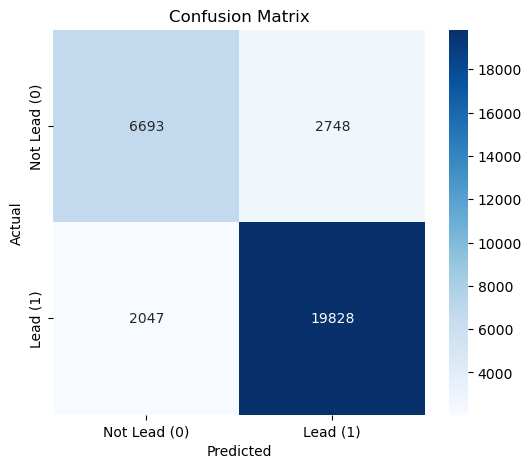

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt


y_train_pred = rf.predict(X_train_processed)
print("\nTraining Set Classification Report:")
print(classification_report(y_train, y_train_pred))

y_test_pred = rf.predict(X_test_processed)
print("\nTesting Set Classification Report:")
print(classification_report(y_test, y_test_pred))
y_pred = rf.predict(X_test_processed)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Lead (0)', 'Lead (1)'],
            yticklabels=['Not Lead (0)', 'Lead (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Plot ROC Curve

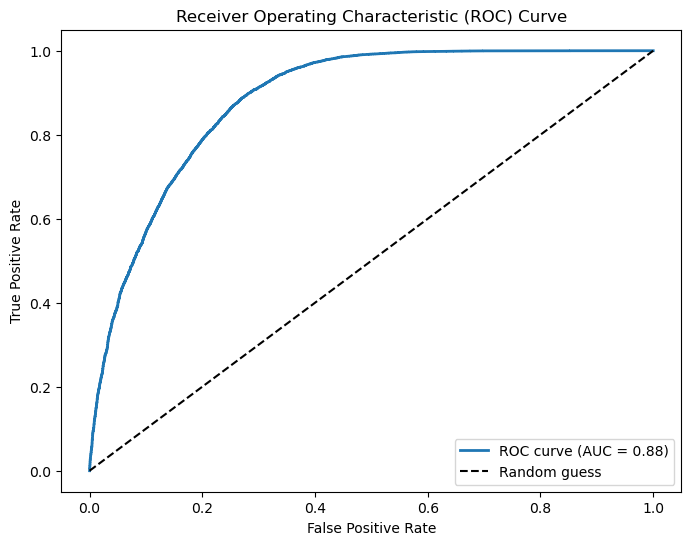

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities for the test set (get probability for the positive class)
y_test_proba = rf.predict_proba(X_test_processed)[:, 1]

# Calculate the false positive rate (fpr), true positive rate (tpr), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Compute the ROC AUC score
roc_auc = roc_auc_score(y_test, y_test_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})", lw=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.show()

/var/folders/z4/gnmh6c053_320_y589_vnxk00000gn/T/ipykernel_6527/306261587.py:5: DtypeWarning: Columns (52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('merged_data.csv')


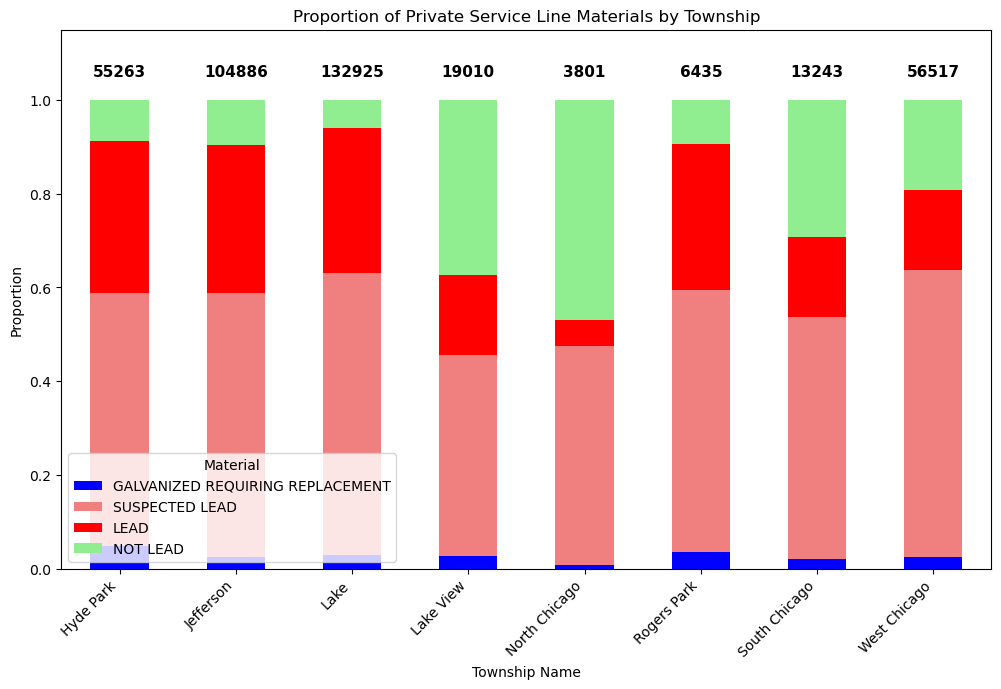

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('merged_data.csv')


township_counts = df['township_name'].value_counts()

valid_townships = township_counts[township_counts > 1000].index
df_filtered = df[df['township_name'].isin(valid_townships)]


material_counts = df_filtered.groupby('township_name')['Private Service Line Material'].value_counts(normalize=True).unstack()

column_order = ['GALVANIZED REQUIRING REPLACEMENT', 'SUSPECTED LEAD', 'LEAD', 'NOT LEAD']
material_counts = material_counts[column_order if set(column_order).issubset(material_counts.columns) else material_counts.columns]
colors = {
    'LEAD': 'red',
    'SUSPECTED LEAD': 'lightcoral',
    'NOT LEAD': 'lightgreen',
    'GALVANIZED REQUIRING REPLACEMENT': 'blue'
}

column_colors = [colors.get(material, 'gray') for material in material_counts.columns]

fig, ax = plt.subplots(figsize=(12, 7))
material_counts.plot(kind='bar', stacked=True, ax=ax, color=column_colors)
plt.title('Proportion of Private Service Line Materials by Township')
plt.xlabel('Township Name')
plt.ylabel('Proportion')
plt.legend(title='Material')
plt.xticks(rotation=45, ha='right')

for i, township in enumerate(material_counts.index):
    total_count = township_counts.get(township, 0)
    ax.text(i, 1.05, str(total_count), ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, 1.15)  
plt.show()

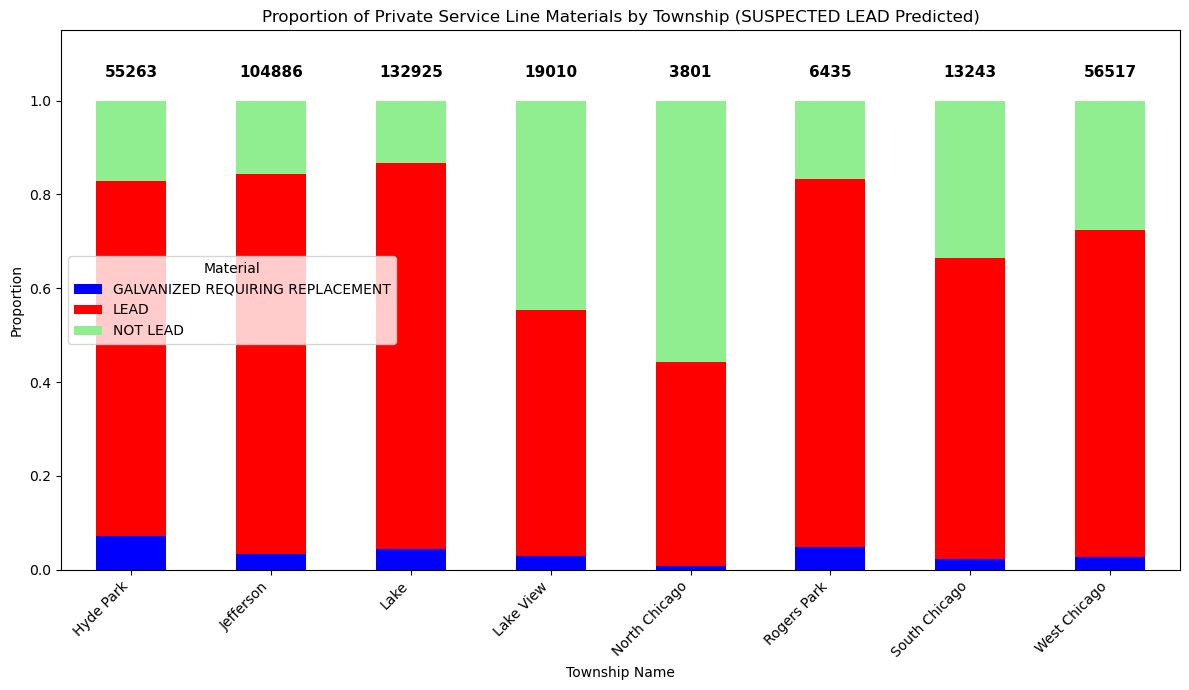

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data.csv')

suspected_df = df[df['Private Service Line Material'] == 'SUSPECTED LEAD'].copy()
X_suspected = suspected_df.drop(columns=['Private Service Line Material'])

X_suspected_processed = preprocessor.transform(X_suspected)

predicted_labels = rf.predict(X_suspected_processed)
suspected_df['Private Service Line Material'] = pd.Series(predicted_labels).map({1: 'LEAD', 0: 'NOT LEAD'})

df_updated = df.copy()
df_updated.loc[suspected_df.index, 'Private Service Line Material'] = suspected_df['Private Service Line Material']

township_counts = df_updated['township_name'].value_counts()

valid_townships = township_counts[township_counts > 1000].index
df_filtered = df_updated[df_updated['township_name'].isin(valid_townships)]

material_counts = df_filtered.groupby('township_name')['Private Service Line Material'].value_counts(normalize=True).unstack()

colors = {
    'LEAD': 'red',
    'NOT LEAD': 'lightgreen',
    'GALVANIZED REQUIRING REPLACEMENT': 'blue'
}
column_colors = [colors.get(material, 'gray') for material in material_counts.columns]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
material_counts.plot(kind='bar', stacked=True, ax=ax, color=column_colors)
plt.title('Proportion of Private Service Line Materials by Township (SUSPECTED LEAD Predicted)')
plt.xlabel('Township Name')
plt.ylabel('Proportion')
plt.legend(title='Material')
plt.xticks(rotation=45, ha='right')

# Add total counts
for i, township in enumerate(material_counts.index):
    total_count = township_counts.get(township, 0)
    ax.text(i, 1.05, str(total_count), ha='center', fontsize=11, fontweight='bold')

plt.ylim(0, 1.15)
plt.tight_layout()
plt.show()